In [31]:
import os
import time
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from typing import Annotated, TypedDict,Literal,List
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage,HumanMessage
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

In [32]:
load_dotenv()

True

In [33]:
llm=ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
)

In [34]:
class JokeState(TypedDict):
    topic:str
    joke:str
    Explanation:str
    

In [35]:
graph=StateGraph(JokeState)

In [41]:
def gen_joke(state:JokeState)->JokeState:
    topic=state["topic"]
    prompt=f"genrate a joke about the topic {topic} ."
    messages=[HumanMessage(content=prompt)]
    response=llm.invoke(messages)
    return {'joke':response.content}
def explain_joke(state:JokeState)->JokeState:
    joke=state["joke"]
    prompt=f"explain the joke {joke} in simple words."
    print("waiting for 30 seconds before calling the LLM to avoid rate limit")
    time.sleep(30)
    messages=[HumanMessage(content=prompt)]
    response=llm.invoke(messages)
    return {'Explanation':response.content}

In [42]:
graph.add_node("Gen Joke",gen_joke)
graph.add_node("Explain Joke",explain_joke)
graph.add_edge(START,"Gen Joke")
graph.add_edge("Gen Joke","Explain Joke")
graph.add_edge("Explain Joke",END)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Node `Gen Joke` already present.

In [43]:
checkpointer =InMemorySaver()
workflow=graph.compile(checkpointer=checkpointer)

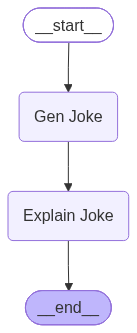

In [44]:
workflow

In [45]:
thread_id="1"
config={'configurable':{"thread_id":thread_id}}
final_state=workflow.invoke({"topic":"programming"},config=config)

KeyboardInterrupt: 

In [24]:
final_state

{'topic': 'programming',
 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.',
 'Explanation': 'The joke is a play on words. It says "light attracts bugs." But in a normal context, when people say "bugs," they\'re usually talking about small insects or errors in a program.\n\nIn this joke, the word "bugs" has a double meaning:\n\n- Insects are attracted to light.\n- "Bugs" can also refer to errors or problems in a program.\n\nSo, the joke is saying that programmers prefer dark mode because it reduces the number of errors (bugs) in their code, but it\'s also a pun on the fact that insects are attracted to light, not errors in code.'}

In [46]:
workflow.get_state(config=config)

StateSnapshot(values={'topic': 'programming', 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.'}, next=('Explain Joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18dd89-20c7-6e52-8001-d29336ee5a59'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-01T18:41:12.794043+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18dd89-1f2f-687e-8000-5c4f78143018'}}, tasks=(PregelTask(id='35ad30e5-87f3-9a11-024f-de961f68de28', name='Explain Joke', path=('__pregel_pull', 'Explain Joke'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [47]:
list(workflow.get_state_history(config=config))

[StateSnapshot(values={'topic': 'programming', 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.'}, next=('Explain Joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18dd89-20c7-6e52-8001-d29336ee5a59'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-01T18:41:12.794043+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18dd89-1f2f-687e-8000-5c4f78143018'}}, tasks=(PregelTask(id='35ad30e5-87f3-9a11-024f-de961f68de28', name='Explain Joke', path=('__pregel_pull', 'Explain Joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'programming'}, next=('Gen Joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18dd89-1f2f-687e-8000-5c4f78143018'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-01T18:41:12.626789+00:00', parent_

In [ ]:
final_state=workflow.invoke(None,config=config) #this code is for checking fault tolerance, it will resume from the last state and continue the workflow

In [49]:
final_state

{'topic': 'programming',
 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.',
 'Explanation': 'This joke is a play on words. In simple terms, it\'s a pun. \n\n"Dark mode" is a feature in some software that changes the background color to dark, making it easier on the eyes. \n\nThe joke says "light attracts bugs." Here, "bugs" has a double meaning:\n\n1. In software development, "bugs" refers to errors or glitches in the code.\n2. In the real world, "bugs" are small insects, and light can attract them.\n\nSo, the joke is saying that programmers prefer dark mode because the "light" (as in the background color) is attracting the kind of "bugs" (errors) that they don\'t want in their code.'}

In [50]:
workflow.get_state(config=config)

StateSnapshot(values={'topic': 'programming', 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.', 'Explanation': 'This joke is a play on words. In simple terms, it\'s a pun. \n\n"Dark mode" is a feature in some software that changes the background color to dark, making it easier on the eyes. \n\nThe joke says "light attracts bugs." Here, "bugs" has a double meaning:\n\n1. In software development, "bugs" refers to errors or glitches in the code.\n2. In the real world, "bugs" are small insects, and light can attract them.\n\nSo, the joke is saying that programmers prefer dark mode because the "light" (as in the background color) is attracting the kind of "bugs" (errors) that they don\'t want in their code.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f18dd8d-118f-63e6-8002-fa062a6ea309'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-01T18:42:58.572135+00:00', parent_config={'confi